# The idea of HA optimality

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

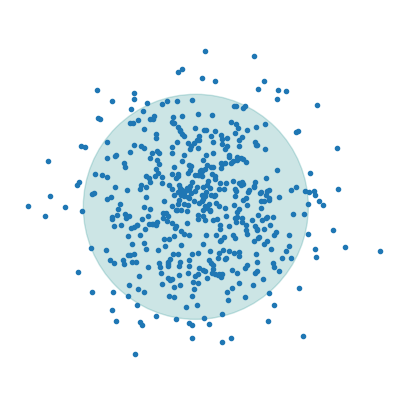

In [3]:
# Create a fake Gaussian city
def simplistic_city():
    n_points = 500
    x = np.random.normal(size=(n_points, 1))
    y = np.random.normal(size=(n_points, 1))
    
    plt.plot(x, y,'.');
    plt.gca().add_patch(plt.Circle((0,0), 2, color='teal', alpha=0.2));
    plt.axis('off')
    plt.axis('equal')
    
plt.figure(figsize=(5,5))
simplistic_city()

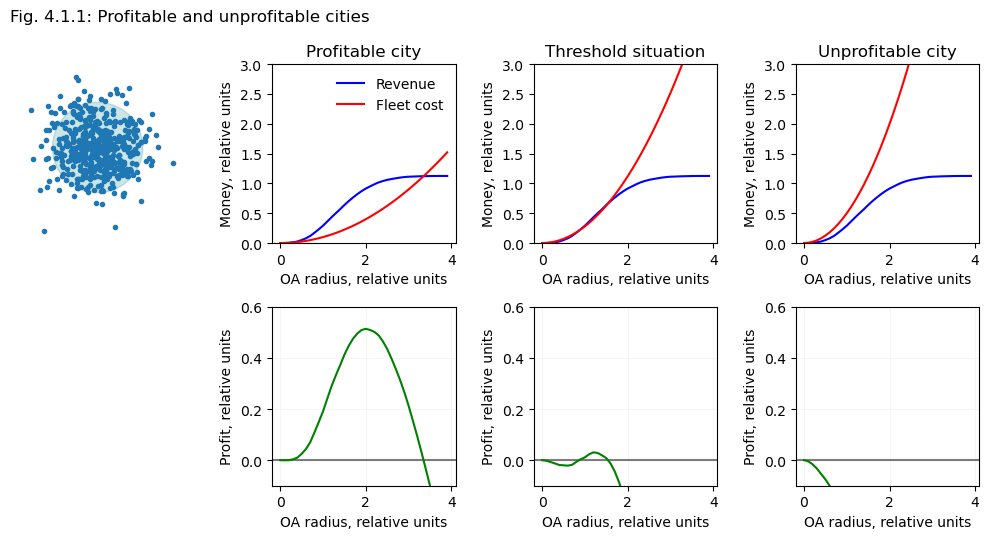

In [21]:
# Model different financial situations for this city
n_points = 10000
x = np.random.normal(size=(n_points, 1))
y = np.random.normal(size=(n_points, 1))


def naive_ha_plot(c=1, title='', legend=True, delta=False):    
    levels = np.arange(0, 4, 0.1)
    n = len(levels)
    revenue = np.zeros(n)
    cost = np.zeros(n)
    
    for i in range(n):
        r = levels[i]        
        mask = (np.sqrt(np.square(x).sum(axis=1)) < r) & (np.sqrt(np.square(y).sum(axis=1)) < r)
        dist = np.sqrt(np.square(x-y).sum(axis=1))
        revenue[i] = dist[mask].sum()/n_points
        cost[i] = np.square(r)

    if not delta:  # Two plots    
        plt.plot(levels, revenue, 'b-', label='Revenue');
        plt.plot(levels, cost*c, 'r-', label='Fleet cost')
        plt.xlabel("OA radius, relative units");
        plt.ylabel("Money, relative units");
        plt.ylim([0, 3]);
        plt.title(title)
        if legend:
            plt.legend(frameon=False)
        return
    else: # delta plot
        plt.axhline(0, color='k', alpha=0.5)
        plt.plot(levels, revenue - cost*c, 'g-');        
        plt.xlabel("OA radius, relative units");
        plt.ylabel("Profit, relative units");
        plt.ylim([-0.1, 0.6]);
        plt.grid(alpha=0.1)
        
    
plt.figure(figsize=(10, 5.5))
plt.subplot(241); simplistic_city()
plt.title("Fig. 4.1.1: Profitable and unprofitable cities\n \n ", loc='left')
plt.subplot(242); naive_ha_plot(0.10, "Profitable city")
plt.subplot(243); naive_ha_plot(0.28, "Threshold situation", legend=False)
plt.subplot(244); naive_ha_plot(0.5, "Unprofitable city", legend=False)

plt.subplot(246); naive_ha_plot(0.10, delta=True)
plt.subplot(247); naive_ha_plot(0.28, delta=True)
plt.subplot(248); naive_ha_plot(0.5, delta=True)

plt.tight_layout()
plt.savefig("../figures/04oa_01optimality.svg", dpi=300)